In [1]:
48+8

56

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importing CSV Dataset

In [4]:
df = pd.read_csv("Fitness_Health_Tracking_Dataset.csv")
df.head()


,User_ID,Full Name,Date,Age,Gender,Height (cm),Weight (kg),Steps_Taken,Calories_Burned,Hours_Slept,Water_Intake (Liters),Active_Minutes,Heart_Rate (bpm),Workout_Type,Stress_Level (1-10),Mood
0,1,Sara Martinez,01-01-2023 00:00,19,Female,191,80,11405,1862,7.021201,3.440508,80.0,84.0,Yoga,2,Happy
1,1,Sara Martinez,02-01-2023 00:00,19,Female,191,80,7010,1806,NaN,3.103590,47.0,72.0,Cardio,9,Neutral
2,1,Sara Martinez,03-01-2023 00:00,19,Female,191,80,18942,2274,8.167817,3.814843,46.0,85.0,Yoga,6,Sad
3,1,Sara Martinez,04-01-2023 00:00,19,Female,191,80,13778,2656,7.453552,3.508636,105.0,77.0,Yoga,2,Sad
4,1,Sara Martinez,05-01-2023 00:00,19,Female,191,80,10247,3571,5.132654,NaN,53.0,61.0,Yoga,8,Sad


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36500 entries, 0 to 36499
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   User_ID                36500 non-null  int64  
 1   Full Name              36500 non-null  object 
 2   Date                   36500 non-null  object 
 3   Age                    36500 non-null  int64  
 4   Gender                 36500 non-null  object 
 5   Height (cm)            36500 non-null  int64  
 6   Weight (kg)            36500 non-null  int64  
 7   Steps_Taken            36500 non-null  int64  
 8   Calories_Burned        36500 non-null  int64  
 9   Hours_Slept            32841 non-null  float64
 10  Water_Intake (Liters)  31099 non-null  float64
 11  Active_Minutes         34633 non-null  float64
 12  Heart_Rate (bpm)       34668 non-null  float64
 13  Workout_Type           27308 non-null  object 
 14  Stress_Level (1-10)    36500 non-null  int64  
 15  Mo

In [6]:
df.shape

(36500, 16)

In [7]:
df.describe()

,User_ID,Age,Height (cm),Weight (kg),Steps_Taken,Calories_Burned,Hours_Slept,Water_Intake (Liters),Active_Minutes,Heart_Rate (bpm),Stress_Level (1-10)
count,36500.000000,36500.000000,36500.000000,36500.000000,36500.000000,36500.000000,32841.000000,31099.000000,34633.000000,34668.000000,36500.000000
mean,50.500000,43.160000,172.690000,85.830000,11035.111973,2747.735452,6.492194,2.742529,74.372477,79.574305,5.499260
std,28.866465,13.674046,14.433974,21.567426,5203.268097,723.854309,1.437658,0.720265,26.012433,11.532934,2.881435
min,1.000000,19.000000,150.000000,51.000000,2000.000000,1500.000000,4.000329,1.500416,30.000000,60.000000,1.000000
25%,25.750000,29.000000,160.000000,68.000000,6522.750000,2119.000000,5.239025,2.121126,52.000000,70.000000,3.000000
50%,50.500000,44.000000,173.000000,86.000000,11042.000000,2748.000000,6.500790,2.739198,74.000000,80.000000,6.000000
75%,75.250000,56.250000,181.000000,107.000000,15561.500000,3376.000000,7.732830,3.363530,97.000000,90.000000,8.000000
max,100.000000,63.000000,199.000000,118.000000,19999.000000,3999.000000,8.999341,3.999981,119.000000,99.000000,10.000000


In [8]:
df.isnull().sum()

User_ID                     0
Full Name                   0
Date                        0
Age                         0
Gender                      0
Height (cm)                 0
Weight (kg)                 0
Steps_Taken                 0
Calories_Burned             0
Hours_Slept              3659
Water_Intake (Liters)    5401
Active_Minutes           1867
Heart_Rate (bpm)         1832
Workout_Type             9192
Stress_Level (1-10)         0
Mood                        0
dtype: int64

In [9]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)

In [10]:
df.isnull().sum()

User_ID                     0
Full Name                   0
Date                        0
Age                         0
Gender                      0
Height (cm)                 0
Weight (kg)                 0
Steps_Taken                 0
Calories_Burned             0
Hours_Slept              3659
Water_Intake (Liters)    5401
Active_Minutes           1867
Heart_Rate (bpm)         1832
Workout_Type             9192
Stress_Level (1-10)         0
Mood                        0
dtype: int64

In [11]:
df.numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
df.numeric_columns

C:\Users\kushw\AppData\Local\Temp\ipykernel_11788\2134220839.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()


['User_ID',
 'Age',
 'Height (cm)',
 'Weight (kg)',
 'Steps_Taken',
 'Calories_Burned',
 'Hours_Slept',
 'Water_Intake (Liters)',
 'Active_Minutes',
 'Heart_Rate (bpm)',
 'Stress_Level (1-10)']

In [12]:
df.groupby("User_ID")[[
    "Hours_Slept",
    "Water_Intake (Liters)",
    "Active_Minutes",
    "Heart_Rate (bpm)"
]].apply(lambda x: x.isnull().sum())

,Hours_Slept,Water_Intake (Liters),Active_Minutes,Heart_Rate (bpm)
User_ID,,,,
1,37,47,19,22
2,43,59,19,12
3,40,53,18,18
4,35,61,20,15
5,46,55,22,20
...,...,...,...,...
96,31,45,16,20
97,30,66,19,19
98,36,52,21,23


In [13]:
df.isnull().sum()

User_ID                     0
Full Name                   0
Date                        0
Age                         0
Gender                      0
Height (cm)                 0
Weight (kg)                 0
Steps_Taken                 0
Calories_Burned             0
Hours_Slept              3659
Water_Intake (Liters)    5401
Active_Minutes           1867
Heart_Rate (bpm)         1832
Workout_Type             9192
Stress_Level (1-10)         0
Mood                        0
dtype: int64

In [14]:
numeric_cols = [
    "Hours_Slept",
    "Water_Intake (Liters)",
    "Active_Minutes",
    "Heart_Rate (bpm)"
]

df[numeric_cols] = df.groupby("User_ID")[numeric_cols].transform(
    lambda x: x.interpolate(method="linear")
)
df.isnull().sum()

User_ID                     0
Full Name                   0
Date                        0
Age                         0
Gender                      0
Height (cm)                 0
Weight (kg)                 0
Steps_Taken                 0
Calories_Burned             0
Hours_Slept                 8
Water_Intake (Liters)      10
Active_Minutes              6
Heart_Rate (bpm)            5
Workout_Type             9192
Stress_Level (1-10)         0
Mood                        0
dtype: int64

In [15]:
df[numeric_cols] = df.groupby("User_ID")[numeric_cols].transform(
    lambda x: x.ffill().bfill()
)




In [16]:
df["Workout_Type"] = df["Workout_Type"].fillna("No Workout")
df.isnull().sum()

User_ID                  0
Full Name                0
Date                     0
Age                      0
Gender                   0
Height (cm)              0
Weight (kg)              0
Steps_Taken              0
Calories_Burned          0
Hours_Slept              0
Water_Intake (Liters)    0
Active_Minutes           0
Heart_Rate (bpm)         0
Workout_Type             0
Stress_Level (1-10)      0
Mood                     0
dtype: int64

In [17]:
df = pd.read_csv("Fitness_Health_Tracking_Dataset.csv")
df.head()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36500 entries, 0 to 36499
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   User_ID                36500 non-null  int64  
 1   Full Name              36500 non-null  object 
 2   Date                   36500 non-null  object 
 3   Age                    36500 non-null  int64  
 4   Gender                 36500 non-null  object 
 5   Height (cm)            36500 non-null  int64  
 6   Weight (kg)            36500 non-null  int64  
 7   Steps_Taken            36500 non-null  int64  
 8   Calories_Burned        36500 non-null  int64  
 9   Hours_Slept            32841 non-null  float64
 10  Water_Intake (Liters)  31099 non-null  float64
 11  Active_Minutes         34633 non-null  float64
 12  Heart_Rate (bpm)       34668 non-null  float64
 13  Workout_Type           27308 non-null  object 
 14  Stress_Level (1-10)    36500 non-null  int64  
 15  Mo


Date Range:
Start Date: 01-01-2023 00:00
End Date: 31-12-2023 00:00


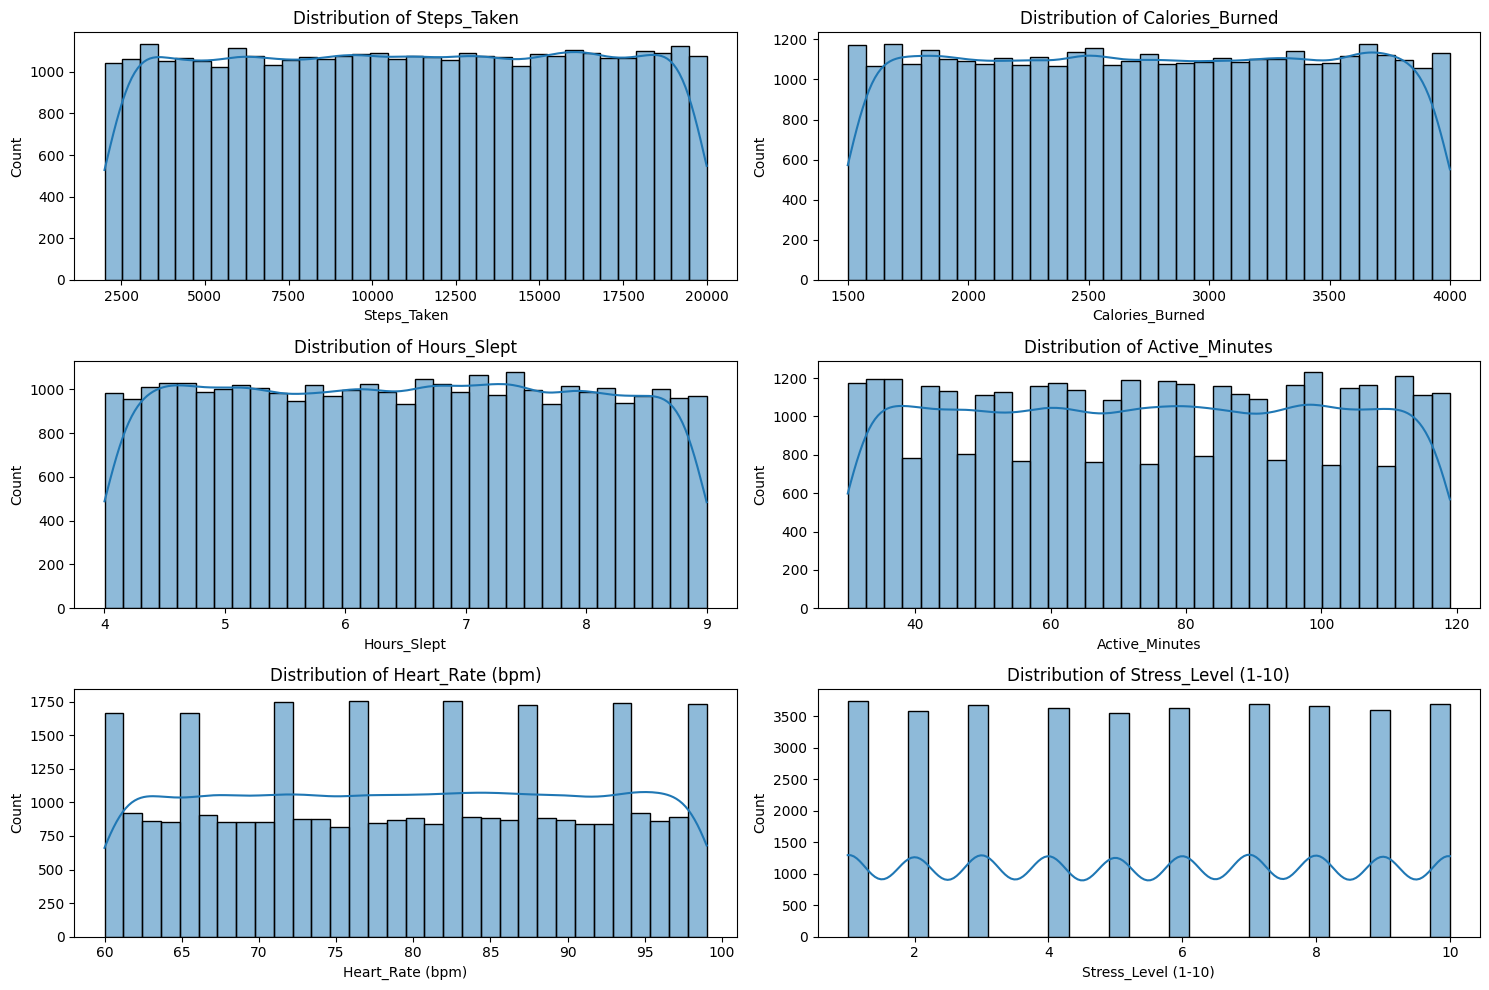

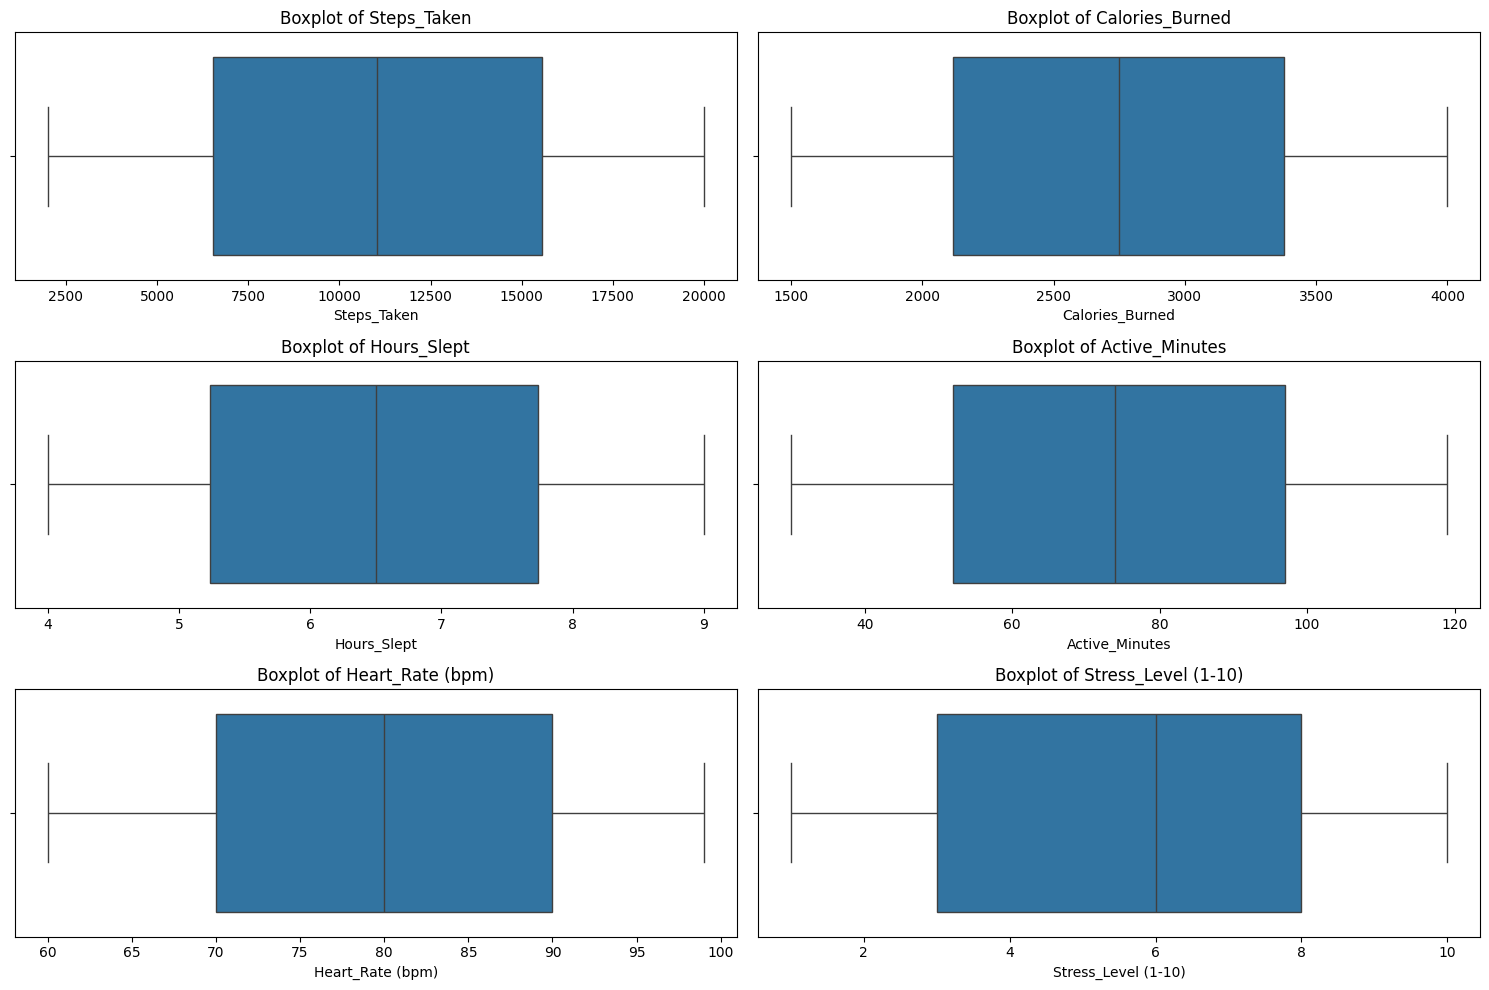

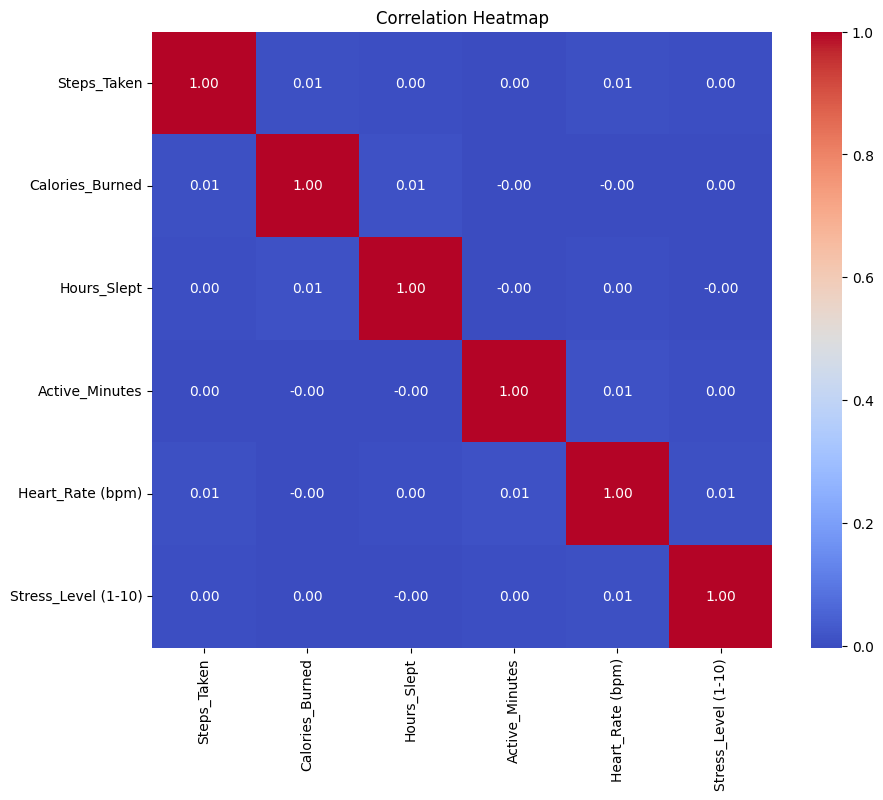

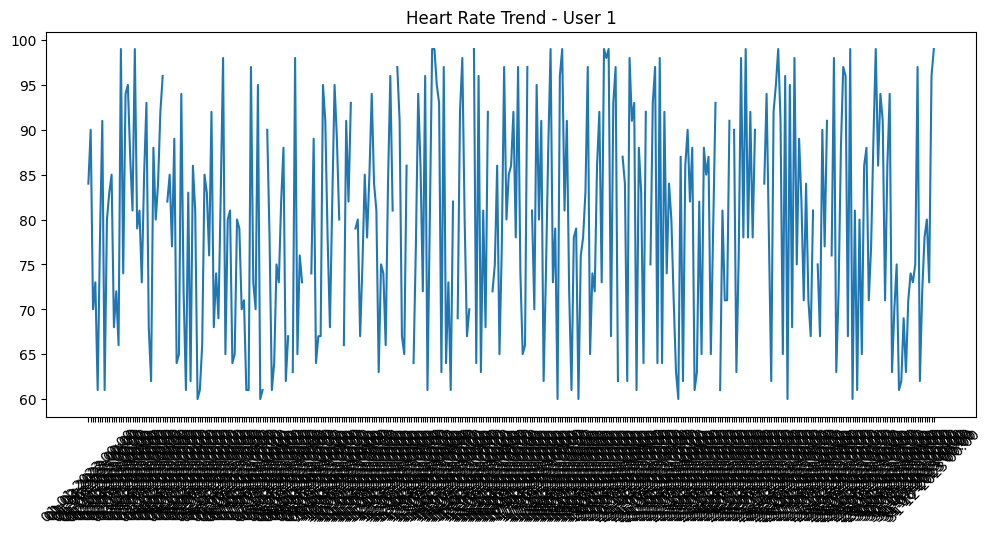


User-Level Average Summary:

          Steps_Taken  Calories_Burned  Hours_Slept  Active_Minutes  \
User_ID                                                               
1        11352.600000      2723.736986     6.471166       74.245665   
2        10520.542466      2812.512329     6.475874       74.083815   
3        11096.704110      2751.742466     6.409910       73.463977   
4        11492.358904      2774.928767     6.478353       76.092754   
5        10973.901370      2688.419178     6.419847       76.180758   

         Heart_Rate (bpm)  Stress_Level (1-10)  
User_ID                                         
1               79.338192             5.589041  
2               80.541076             5.471233  
3               79.582133             5.383562  
4               80.982857             5.339726  
5               79.272464             5.438356  


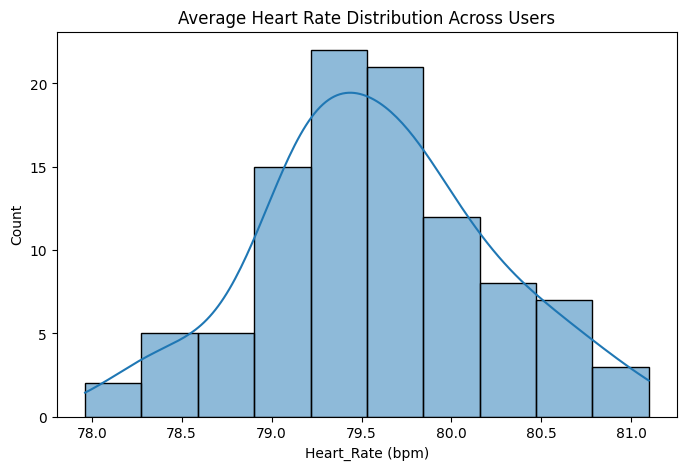

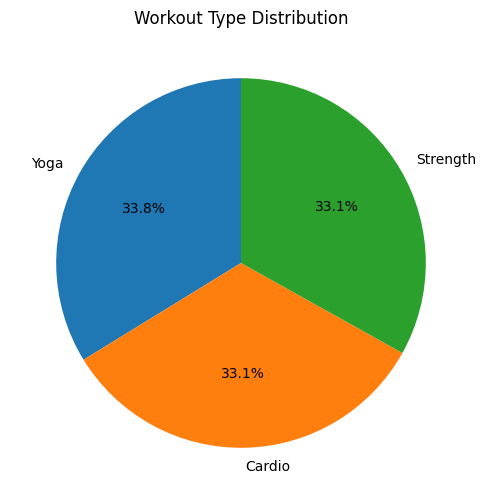

In [18]:
# ================================
# PROFESSIONAL EDA PIPELINE
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. DATASET OVERVIEW
# -------------------------------

# -------------------------------
# 2. DATA QUALITY CHECKS
# -------------------------------

print("\nDate Range:")
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

# -------------------------------
# 3. UNIVARIATE ANALYSIS
# -------------------------------

numeric_cols = [
    "Steps_Taken",
    "Calories_Burned",
    "Hours_Slept",
    "Active_Minutes",
    "Heart_Rate (bpm)",
    "Stress_Level (1-10)"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols):
    plt.subplot(3,2,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

# -------------------------------
# 4. OUTLIER DETECTION (BOXPLOTS)
# -------------------------------

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols):
    plt.subplot(3,2,i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

# -------------------------------
# 5. CORRELATION ANALYSIS
# -------------------------------

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 6. TIME-SERIES TREND (ONE USER)
# -------------------------------

user_id = df["User_ID"].iloc[0]
user_data = df[df["User_ID"] == user_id].sort_values("Date")

plt.figure(figsize=(12,5))
plt.plot(user_data["Date"], user_data["Heart_Rate (bpm)"])
plt.title(f"Heart Rate Trend - User {user_id}")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 7. USER-LEVEL AGGREGATION
# -------------------------------

user_summary = df.groupby("User_ID")[numeric_cols].mean()

print("\nUser-Level Average Summary:\n")
print(user_summary.head())

plt.figure(figsize=(8,5))
sns.histplot(user_summary["Heart_Rate (bpm)"], kde=True)
plt.title("Average Heart Rate Distribution Across Users")
plt.show()




workout_counts = df["Workout_Type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(workout_counts,
        labels=workout_counts.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title("Workout Type Distribution")
plt.show()

